# Notebook 3: Severity Classification (Local, ResNet-18)

**Goal:** Train a 3-class classifier (minor / moderate / severe) on crops from CarDD damage regions.

**Approach:**
1. For each labeled damage in CarDD, crop the bounding-box region
2. Map CarDD's 11 fine-grained classes → 3 severity buckets
3. Save crops in `data/severity_crops/{split}/{minor|moderate|severe}/`
4. Train ResNet-18 (transfer learning) on the crops

**Expected on RTX 5070:** ~5-10 minutes for 15 epochs.

**Target:** ≥75% val accuracy (small dataset — don't expect miracles).


## 1. Load paths & confirm GPU

In [1]:
import os, json, torch

with open('dataset_paths.json') as f:
    paths = json.load(f)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print("Device:", device)
print("CarDD dir:", paths['cardd_dir'])

Device: cuda
CarDD dir: d:\VIT\Sem-5\AI\Project\New\data\cardd


## 2. CarDD → severity mapping

In [2]:
import yaml

with open(paths['cardd_yaml']) as f:
    CARDD_NAMES = yaml.safe_load(f)['names']

print("CarDD classes:")
for i, n in enumerate(CARDD_NAMES):
    print(f"  {i}: {n}")

CarDD classes:
  0: car-part-crack
  1: detachment
  2: flat-tire
  3: glass-crack
  4: lamp-crack
  5: minor-deformation
  6: moderate-deformation
  7: paint-chips
  8: scratches
  9: severe-deformation
  10: side-mirror-crack


In [3]:
# Mapping validated from the CarDD data.yaml (11 classes)
SEVERITY_MAP = {
    # minor
    'paint-chips':          'minor',
    'scratches':            'minor',
    'minor-deformation':    'minor',

    # moderate
    'car-part-crack':       'moderate',
    'glass-crack':          'moderate',
    'lamp-crack':           'moderate',
    'side-mirror-crack':    'moderate',
    'moderate-deformation': 'moderate',

    # severe
    'severe-deformation':   'severe',
    'detachment':           'severe',
    'flat-tire':            'severe',
}

# Build class-id -> severity mapping
id_to_severity = {}
missing = []
for i, n in enumerate(CARDD_NAMES):
    if n in SEVERITY_MAP:
        id_to_severity[i] = SEVERITY_MAP[n]
    else:
        missing.append(n)

print("Mapped classes:")
for i, s in id_to_severity.items():
    print(f"  {i} ({CARDD_NAMES[i]:22s}) -> {s}")

if missing:
    print(f"\nWARNING - unmapped: {missing}")

Mapped classes:
  0 (car-part-crack        ) -> moderate
  1 (detachment            ) -> severe
  2 (flat-tire             ) -> severe
  3 (glass-crack           ) -> moderate
  4 (lamp-crack            ) -> moderate
  5 (minor-deformation     ) -> minor
  6 (moderate-deformation  ) -> moderate
  7 (paint-chips           ) -> minor
  8 (scratches             ) -> minor
  9 (severe-deformation    ) -> severe
  10 (side-mirror-crack     ) -> moderate


## 3. Crop damage regions and organize by severity

In [4]:
import glob, cv2, os
from tqdm import tqdm

CROP_DIR = "./data/severity_crops"
for split in ['train', 'valid', 'test']:
    for sev in ['minor', 'moderate', 'severe']:
        os.makedirs(f"{CROP_DIR}/{split}/{sev}", exist_ok=True)

def yolo_to_xyxy(x, y, w, h, W, H):
    x1 = int((x - w/2) * W); y1 = int((y - h/2) * H)
    x2 = int((x + w/2) * W); y2 = int((y + h/2) * H)
    return max(0, x1), max(0, y1), min(W, x2), min(H, y2)

crop_count = {}
for split in ['train', 'valid', 'test']:
    lbl_dir = f"{paths['cardd_dir']}/{split}/labels"
    img_dir = f"{paths['cardd_dir']}/{split}/images"
    lbls = glob.glob(f"{lbl_dir}/*.txt")

    counts_by_sev = {'minor': 0, 'moderate': 0, 'severe': 0}

    for lf in tqdm(lbls, desc=split):
        stem = os.path.splitext(os.path.basename(lf))[0]
        img_path = None
        for ext in ['.jpg', '.jpeg', '.png']:
            p = f"{img_dir}/{stem}{ext}"
            if os.path.exists(p):
                img_path = p; break
        if not img_path: continue

        img = cv2.imread(img_path)
        if img is None: continue
        H, W = img.shape[:2]

        with open(lf) as f:
            for i, line in enumerate(f):
                parts = line.strip().split()
                if len(parts) < 5: continue
                cid = int(parts[0])
                if cid not in id_to_severity: continue
                sev = id_to_severity[cid]
                x, y, w, h = map(float, parts[1:5])
                x1, y1, x2, y2 = yolo_to_xyxy(x, y, w, h, W, H)
                if x2 - x1 < 20 or y2 - y1 < 20: continue
                crop = img[y1:y2, x1:x2]
                out = f"{CROP_DIR}/{split}/{sev}/{stem}_{i}.jpg"
                cv2.imwrite(out, crop)
                counts_by_sev[sev] += 1

    crop_count[split] = counts_by_sev

print("\nCrops per split per severity:")
for split, d in crop_count.items():
    print(f"  {split:6s}: {d}")

test: 100%|██████████| 204/204 [00:02<00:00, 77.98it/s]


Crops per split per severity:
  train : {'minor': 1403, 'moderate': 1362, 'severe': 193}
  valid : {'minor': 436, 'moderate': 358, 'severe': 45}
  test  : {'minor': 203, 'moderate': 186, 'severe': 21}


## 4. Build dataloaders

In [5]:
from torch.utils.data import DataLoader
from torchvision import datasets, transforms

train_tf = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.ColorJitter(0.2, 0.2, 0.2),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225]),
])
eval_tf = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225]),
])

train_ds = datasets.ImageFolder(f"{CROP_DIR}/train", transform=train_tf)
val_ds   = datasets.ImageFolder(f"{CROP_DIR}/valid", transform=eval_tf)

train_loader = DataLoader(train_ds, batch_size=32, shuffle=True, num_workers=2)
val_loader   = DataLoader(val_ds,   batch_size=32, shuffle=False, num_workers=2)

print("Classes:", train_ds.classes)
print(f"Train: {len(train_ds)}, Val: {len(val_ds)}")

Classes: ['minor', 'moderate', 'severe']
Train: 2958, Val: 839


## 5. Model + training

In [6]:
import torch.nn as nn
from torchvision import models

model = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)
model.fc = nn.Linear(model.fc.in_features, 3)
model = model.to(device)

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)

In [7]:
EPOCHS = 15
best_val_acc = 0.0
history = {'train_loss': [], 'val_loss': [], 'val_acc': []}

for epoch in range(EPOCHS):
    # train
    model.train()
    train_loss = 0
    for imgs, labels in train_loader:
        imgs, labels = imgs.to(device), labels.to(device)
        optimizer.zero_grad()
        loss = criterion(model(imgs), labels)
        loss.backward()
        optimizer.step()
        train_loss += loss.item() * imgs.size(0)
    train_loss /= len(train_ds)

    # val
    model.eval()
    val_loss = 0; correct = 0
    with torch.no_grad():
        for imgs, labels in val_loader:
            imgs, labels = imgs.to(device), labels.to(device)
            out = model(imgs)
            val_loss += criterion(out, labels).item() * imgs.size(0)
            correct += (out.argmax(1) == labels).sum().item()
    val_loss /= len(val_ds); val_acc = correct / len(val_ds)

    history['train_loss'].append(train_loss)
    history['val_loss'].append(val_loss)
    history['val_acc'].append(val_acc)

    print(f"Epoch {epoch+1:2d}/{EPOCHS}  train_loss={train_loss:.3f}  val_loss={val_loss:.3f}  val_acc={val_acc:.3f}")

    if val_acc > best_val_acc:
        best_val_acc = val_acc
        os.makedirs('models', exist_ok=True)
        torch.save({
            'state_dict': model.state_dict(),
            'classes': train_ds.classes,
        }, 'models/severity_best.pt')
        print(f"  -> saved new best (val_acc={val_acc:.3f})")

Epoch  1/15  train_loss=0.811  val_loss=0.673  val_acc=0.672
  -> saved new best (val_acc=0.672)
Epoch  2/15  train_loss=0.516  val_loss=0.661  val_acc=0.713
  -> saved new best (val_acc=0.713)
Epoch  3/15  train_loss=0.366  val_loss=0.746  val_acc=0.700
Epoch  4/15  train_loss=0.267  val_loss=0.883  val_acc=0.678
Epoch  5/15  train_loss=0.226  val_loss=0.817  val_acc=0.687
Epoch  6/15  train_loss=0.155  val_loss=0.942  val_acc=0.697
Epoch  7/15  train_loss=0.102  val_loss=1.010  val_acc=0.691
Epoch  8/15  train_loss=0.129  val_loss=0.999  val_acc=0.696
Epoch  9/15  train_loss=0.104  val_loss=0.958  val_acc=0.681
Epoch 10/15  train_loss=0.087  val_loss=1.031  val_acc=0.676
Epoch 11/15  train_loss=0.060  val_loss=1.109  val_acc=0.689
Epoch 12/15  train_loss=0.057  val_loss=1.078  val_acc=0.700
Epoch 13/15  train_loss=0.043  val_loss=1.095  val_acc=0.702
Epoch 14/15  train_loss=0.050  val_loss=1.264  val_acc=0.684
Epoch 15/15  train_loss=0.073  val_loss=1.229  val_acc=0.681


## 6. Evaluate best model

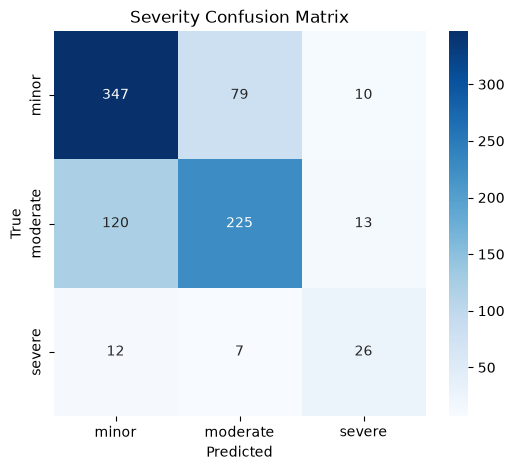

              precision    recall  f1-score   support

       minor       0.72      0.80      0.76       436
    moderate       0.72      0.63      0.67       358
      severe       0.53      0.58      0.55        45

    accuracy                           0.71       839
   macro avg       0.66      0.67      0.66       839
weighted avg       0.71      0.71      0.71       839



In [8]:
import numpy as np
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns
import matplotlib.pyplot as plt

ckpt = torch.load('models/severity_best.pt', map_location=device)
model.load_state_dict(ckpt['state_dict'])
model.eval()

all_preds, all_labels = [], []
with torch.no_grad():
    for imgs, labels in val_loader:
        imgs = imgs.to(device)
        preds = model(imgs).argmax(1).cpu().numpy()
        all_preds.extend(preds); all_labels.extend(labels.numpy())

cm = confusion_matrix(all_labels, all_preds)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d',
            xticklabels=ckpt['classes'], yticklabels=ckpt['classes'], cmap='Blues')
plt.ylabel('True'); plt.xlabel('Predicted'); plt.title('Severity Confusion Matrix')
plt.show()

print(classification_report(all_labels, all_preds, target_names=ckpt['classes']))

## 7. Training curves

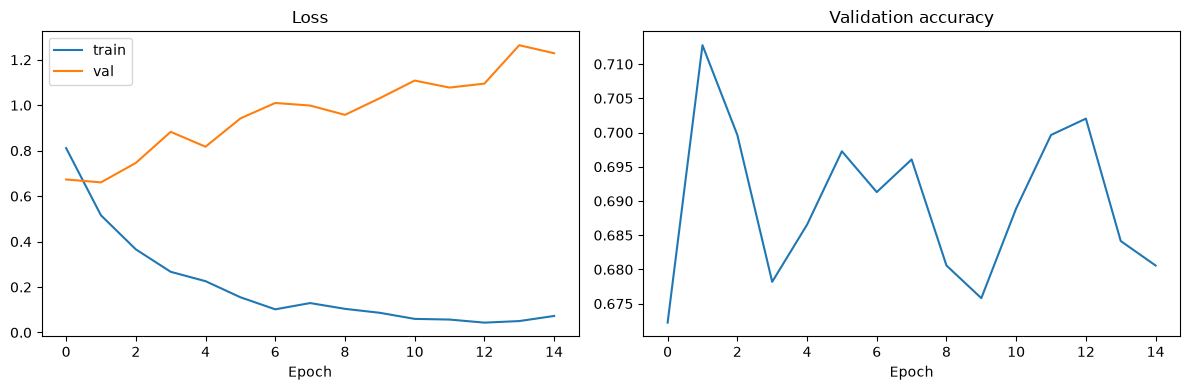

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(history['train_loss'], label='train')
axes[0].plot(history['val_loss'],   label='val')
axes[0].set_title('Loss'); axes[0].set_xlabel('Epoch'); axes[0].legend()
axes[1].plot(history['val_acc'])
axes[1].set_title('Validation accuracy'); axes[1].set_xlabel('Epoch')
plt.tight_layout(); plt.show()

## Done

- ✅ Severity classifier trained
- ✅ `models/severity_best.pt` saved

**Next:** Notebook 4 — cost prediction (no GPU needed, ~1 minute total).